# PowerCo — Feature Engineering

**BCG X Data Science Simulation — Task 3**

This notebook continues from the cleaned PowerCo dataset after EDA.

### Objectives
1. Load the cleaned customer dataset.
2. Recreate Estelle's suggested feature: the December-to-January change in off-peak prices.
3. Create additional business-relevant features using customer, consumption, contract, and price-variation information.
4. Check the resulting feature quality and export the engineered dataset.

> **Important:** Estelle's exact feature requires the original `price_data.csv`. The uploaded cleaned customer file does not contain the monthly raw price observations needed to reproduce that calculation. The notebook therefore includes a safe check: if `price_data.csv` is available, the exact feature is created; otherwise, the notebook continues with the additional features and records the limitation rather than inventing the missing raw data.

## 1. Import packages

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 2. Load the cleaned customer data

In [4]:
# Look for the uploaded cleaned dataset in the current working directory
# and in /mnt/data when running locally in this environment.

candidate_paths = [
    "./clean_data_after_eda.csv",
    "./9211f071-e685-47b7-b40f-658c98942273.csv",
    "/mnt/data/9211f071-e685-47b7-b40f-658c98942273.csv",
]

data_path = next((p for p in candidate_paths if os.path.exists(p)), None)

if data_path is None:
    raise FileNotFoundError(
        "clean_data_after_eda.csv was not found. Place the cleaned PowerCo CSV "
        "in the notebook directory and run this cell again."
    )

df = pd.read_csv(data_path)

# Convert date columns to datetime.
date_columns = ["date_activ", "date_end", "date_modif_prod", "date_renewal"]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print(f"Loaded dataset: {data_path}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Loaded dataset: ./clean_data_after_eda.csv
Rows: 14,606
Columns: 44


In [5]:
df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,var_year_price_off_peak_var,var_year_price_peak_var,var_year_price_mid_peak_var,var_year_price_off_peak_fix,var_year_price_peak_fix,var_year_price_mid_peak_fix,var_year_price_off_peak,var_year_price_peak,var_year_price_mid_peak,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0000,0,0.0000,1.7800,0.1145,0.0981,40.6067,t,0.0000,25.4400,25.4400,2,678.9900,3,lxidpiddsbxsbosboudacockeimpuepw,43.6480,0.0001,0.0000,0.0004,1.1028,49.5507,22.0225,1.1028,49.5507,22.0230,0.0001,0.0000,0.0009,2.0863,99.5305,44.2358,2.0864,99.5306,44.2367,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.9500,0,0.0000,16.2700,0.1457,0.0000,44.3114,f,0.0000,16.3800,16.3800,1,18.8900,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.8000,0.0000,0.0006,0.0000,0.0065,0.0000,0.0000,0.0065,0.0006,0.0000,0.0000,0.0012,0.0000,0.0095,0.0000,0.0000,0.0095,0.0012,0.0000,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.9600,0,0.0000,38.7200,0.1658,0.0879,44.3114,f,0.0000,28.6000,28.6000,1,6.6000,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.8560,0.0000,0.0000,0.0000,0.0077,0.0000,0.0000,0.0077,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0


## 3. Basic data-quality checks

In [6]:
print("Shape:", df.shape)
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(20))

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["id"].duplicated().sum())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

Shape: (14606, 44)

Missing values:


id                             0
channel_sales                  0
pow_max                        0
var_year_price_off_peak_var    0
var_year_price_peak_var        0
var_year_price_mid_peak_var    0
var_year_price_off_peak_fix    0
var_year_price_peak_fix        0
var_year_price_mid_peak_fix    0
var_year_price_off_peak        0
var_year_price_peak            0
var_year_price_mid_peak        0
var_6m_price_off_peak_var      0
var_6m_price_peak_var          0
var_6m_price_mid_peak_var      0
var_6m_price_off_peak_fix      0
var_6m_price_peak_fix          0
var_6m_price_mid_peak_fix      0
var_6m_price_off_peak          0
var_6m_price_peak              0
dtype: int64


Duplicate rows: 0
Duplicate customer IDs: 0

Data types:


,dtype
id,object
channel_sales,object
cons_12m,int64
cons_gas_12m,int64
cons_last_month,int64
date_activ,datetime64[ns]
date_end,datetime64[ns]
date_modif_prod,datetime64[ns]
date_renewal,datetime64[ns]
forecast_cons_12m,float64


## 4. Recreate Estelle's suggested price feature

Estelle's starter notebook calculates:

- `offpeak_diff_dec_january_energy`
- `offpeak_diff_dec_january_power`

The calculation uses the monthly `price_data.csv` file. The code below follows the structure of the provided starter notebook.

In [7]:
price_candidates = [
    "./price_data.csv",
    "/mnt/data/price_data.csv",
]

price_path = next((p for p in price_candidates if os.path.exists(p)), None)

if price_path is not None:
    price_df = pd.read_csv(price_path)
    price_df["price_date"] = pd.to_datetime(price_df["price_date"], errors="coerce")

    # Group off-peak prices by customer and month.
    monthly_price_by_id = (
        price_df
        .groupby(["id", "price_date"])
        .agg({
            "price_off_peak_var": "mean",
            "price_off_peak_fix": "mean"
        })
        .reset_index()
        .sort_values(["id", "price_date"])
    )

    # First and last available monthly observations for each customer.
    jan_prices = monthly_price_by_id.groupby("id").first().reset_index()
    dec_prices = monthly_price_by_id.groupby("id").last().reset_index()

    # Calculate the exact features from Estelle's starter notebook.
    diff = pd.merge(
        dec_prices.rename(columns={
            "price_off_peak_var": "dec_1",
            "price_off_peak_fix": "dec_2"
        }),
        jan_prices.drop(columns="price_date"),
        on="id"
    )

    diff["offpeak_diff_dec_january_energy"] = (
        diff["dec_1"] - diff["price_off_peak_var"]
    )

    diff["offpeak_diff_dec_january_power"] = (
        diff["dec_2"] - diff["price_off_peak_fix"]
    )

    diff = diff[
        [
            "id",
            "offpeak_diff_dec_january_energy",
            "offpeak_diff_dec_january_power"
        ]
    ]

    df = pd.merge(df, diff, on="id", how="left")

    print("Estelle's exact price features were created.")
    display(diff.head())
else:
    # Keep the notebook executable even when only the uploaded cleaned CSV
    # is available. Do not fabricate the missing monthly-price calculation.
    df["offpeak_diff_dec_january_energy"] = np.nan
    df["offpeak_diff_dec_january_power"] = np.nan

    print(
        "price_data.csv was not found. Estelle's exact December-to-January "
        "features are left as NaN. Place price_data.csv beside the notebook "
        "and rerun this section to calculate them exactly."
    )

Estelle's exact price features were created.


,id,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
0,0002203ffbb812588b632b9e628cc38d,-0.0062,0.1629
1,0004351ebdd665e6ee664792efc4fd13,-0.0041,0.1778
2,0010bcc39e42b3c2131ed2ce55246e3c,0.0504,1.5000
3,0010ee3855fdea87602a5b7aba8e42de,-0.0100,0.1629
4,00114d74e963e47177db89bc70108537,-0.0040,-0.0000


In [8]:
# -----------------------------
# Consumption features
# -----------------------------

df["total_consumption_12m"] = (
    df["cons_12m"] + df["cons_gas_12m"]
)

df["gas_consumption_share"] = (
    df["cons_gas_12m"] /
    df["total_consumption_12m"].replace(0, np.nan)
)

df["last_month_consumption_share"] = (
    df["cons_last_month"] /
    df["cons_12m"].replace(0, np.nan)
)

df["forecast_consumption_gap"] = (
    df["forecast_cons_12m"] - df["cons_12m"]
)

df["forecast_consumption_ratio"] = (
    df["forecast_cons_12m"] /
    df["cons_12m"].replace(0, np.nan)
)

# -----------------------------
# Forecast price features
# -----------------------------

df["forecast_energy_price_avg"] = (
    df["forecast_price_energy_off_peak"] +
    df["forecast_price_energy_peak"]
) / 2

df["forecast_energy_price_spread"] = (
    df["forecast_price_energy_peak"] -
    df["forecast_price_energy_off_peak"]
)

# -----------------------------
# Annual price-variation features
# -----------------------------

df["avg_year_variable_price_variation"] = (
    df["var_year_price_off_peak_var"] +
    df["var_year_price_peak_var"] +
    df["var_year_price_mid_peak_var"]
) / 3

df["avg_year_fixed_price_variation"] = (
    df["var_year_price_off_peak_fix"] +
    df["var_year_price_peak_fix"] +
    df["var_year_price_mid_peak_fix"]
) / 3

df["avg_year_total_price_variation"] = (
    df["var_year_price_off_peak"] +
    df["var_year_price_peak"] +
    df["var_year_price_mid_peak"]
) / 3

# -----------------------------
# Six-month price-variation features
# -----------------------------

df["avg_6m_variable_price_variation"] = (
    df["var_6m_price_off_peak_var"] +
    df["var_6m_price_peak_var"] +
    df["var_6m_price_mid_peak_var"]
) / 3

df["avg_6m_fixed_price_variation"] = (
    df["var_6m_price_off_peak_fix"] +
    df["var_6m_price_peak_fix"] +
    df["var_6m_price_mid_peak_fix"]
) / 3

df["avg_6m_total_price_variation"] = (
    df["var_6m_price_off_peak"] +
    df["var_6m_price_peak"] +
    df["var_6m_price_mid_peak"]
) / 3

# Difference between short-term and annual price variation.
df["price_variation_change_6m_vs_year"] = (
    df["avg_6m_total_price_variation"] -
    df["avg_year_total_price_variation"]
)

# -----------------------------
# Customer / contract features
# -----------------------------

df["customer_tenure_days"] = (
    df["date_end"] - df["date_activ"]
).dt.days

df["days_until_renewal"] = (
    df["date_renewal"] - df["date_modif_prod"]
).dt.days

df["days_since_product_modification"] = (
    df["date_end"] - df["date_modif_prod"]
).dt.days

df["has_multiple_products"] = (
    df["nb_prod_act"] > 1
).astype(int)

df["has_gas_customer"] = (
    df["has_gas"].astype(str).str.lower() == "t"
).astype(int)

print("Feature engineering completed.")

Feature engineering completed.


## 6. Inspect the newly created features

In [9]:
new_features = [
    "offpeak_diff_dec_january_energy",
    "offpeak_diff_dec_january_power",
    "total_consumption_12m",
    "gas_consumption_share",
    "last_month_consumption_share",
    "forecast_consumption_gap",
    "forecast_consumption_ratio",
    "forecast_energy_price_avg",
    "forecast_energy_price_spread",
    "avg_year_variable_price_variation",
    "avg_year_fixed_price_variation",
    "avg_year_total_price_variation",
    "avg_6m_variable_price_variation",
    "avg_6m_fixed_price_variation",
    "avg_6m_total_price_variation",
    "price_variation_change_6m_vs_year",
    "customer_tenure_days",
    "days_until_renewal",
    "days_since_product_modification",
    "has_multiple_products",
    "has_gas_customer",
]

display(df[new_features].head())

,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power,total_consumption_12m,gas_consumption_share,last_month_consumption_share,forecast_consumption_gap,forecast_consumption_ratio,forecast_energy_price_avg,forecast_energy_price_spread,avg_year_variable_price_variation,avg_year_fixed_price_variation,avg_year_total_price_variation,avg_6m_variable_price_variation,avg_6m_fixed_price_variation,avg_6m_total_price_variation,price_variation_change_6m_vs_year,customer_tenure_days,days_until_renewal,days_since_product_modification,has_multiple_products,has_gas_customer
0,0.0201,3.7010,54946,1.0000,NaN,0.0000,NaN,0.1063,-0.0163,0.0002,24.2253,24.2255,0.0004,48.6175,48.6179,24.3924,1096,-131,227,1,1
1,-0.0038,0.1778,4660,0.0000,0.0000,"-4,470.0500",0.0408,0.0729,-0.1457,0.0002,0.0022,0.0024,0.0004,0.0032,0.0036,0.0012,2566,2201,2566,0,0
2,-0.0047,0.1778,544,0.0000,0.0000,-496.0400,0.0882,0.1268,-0.0779,0.0000,0.0026,0.0026,0.0000,0.0000,0.0000,-0.0026,2192,1827,2192,0,0
3,-0.0045,0.1778,1584,0.0000,0.0000,"-1,343.9600",0.1515,0.0733,-0.1467,0.0000,0.0022,0.0022,0.0000,0.0000,0.0000,-0.0022,2192,1827,2192,0,0
4,-0.0062,0.1629,4425,0.0000,0.1189,"-3,979.2500",0.1007,0.1085,-0.0169,0.0000,0.0028,0.0028,0.0000,0.0000,0.0000,-0.0028,2245,1881,2245,0,0


## 7. Check feature distributions

Simple histograms help identify skewed variables and unusual values before modeling.

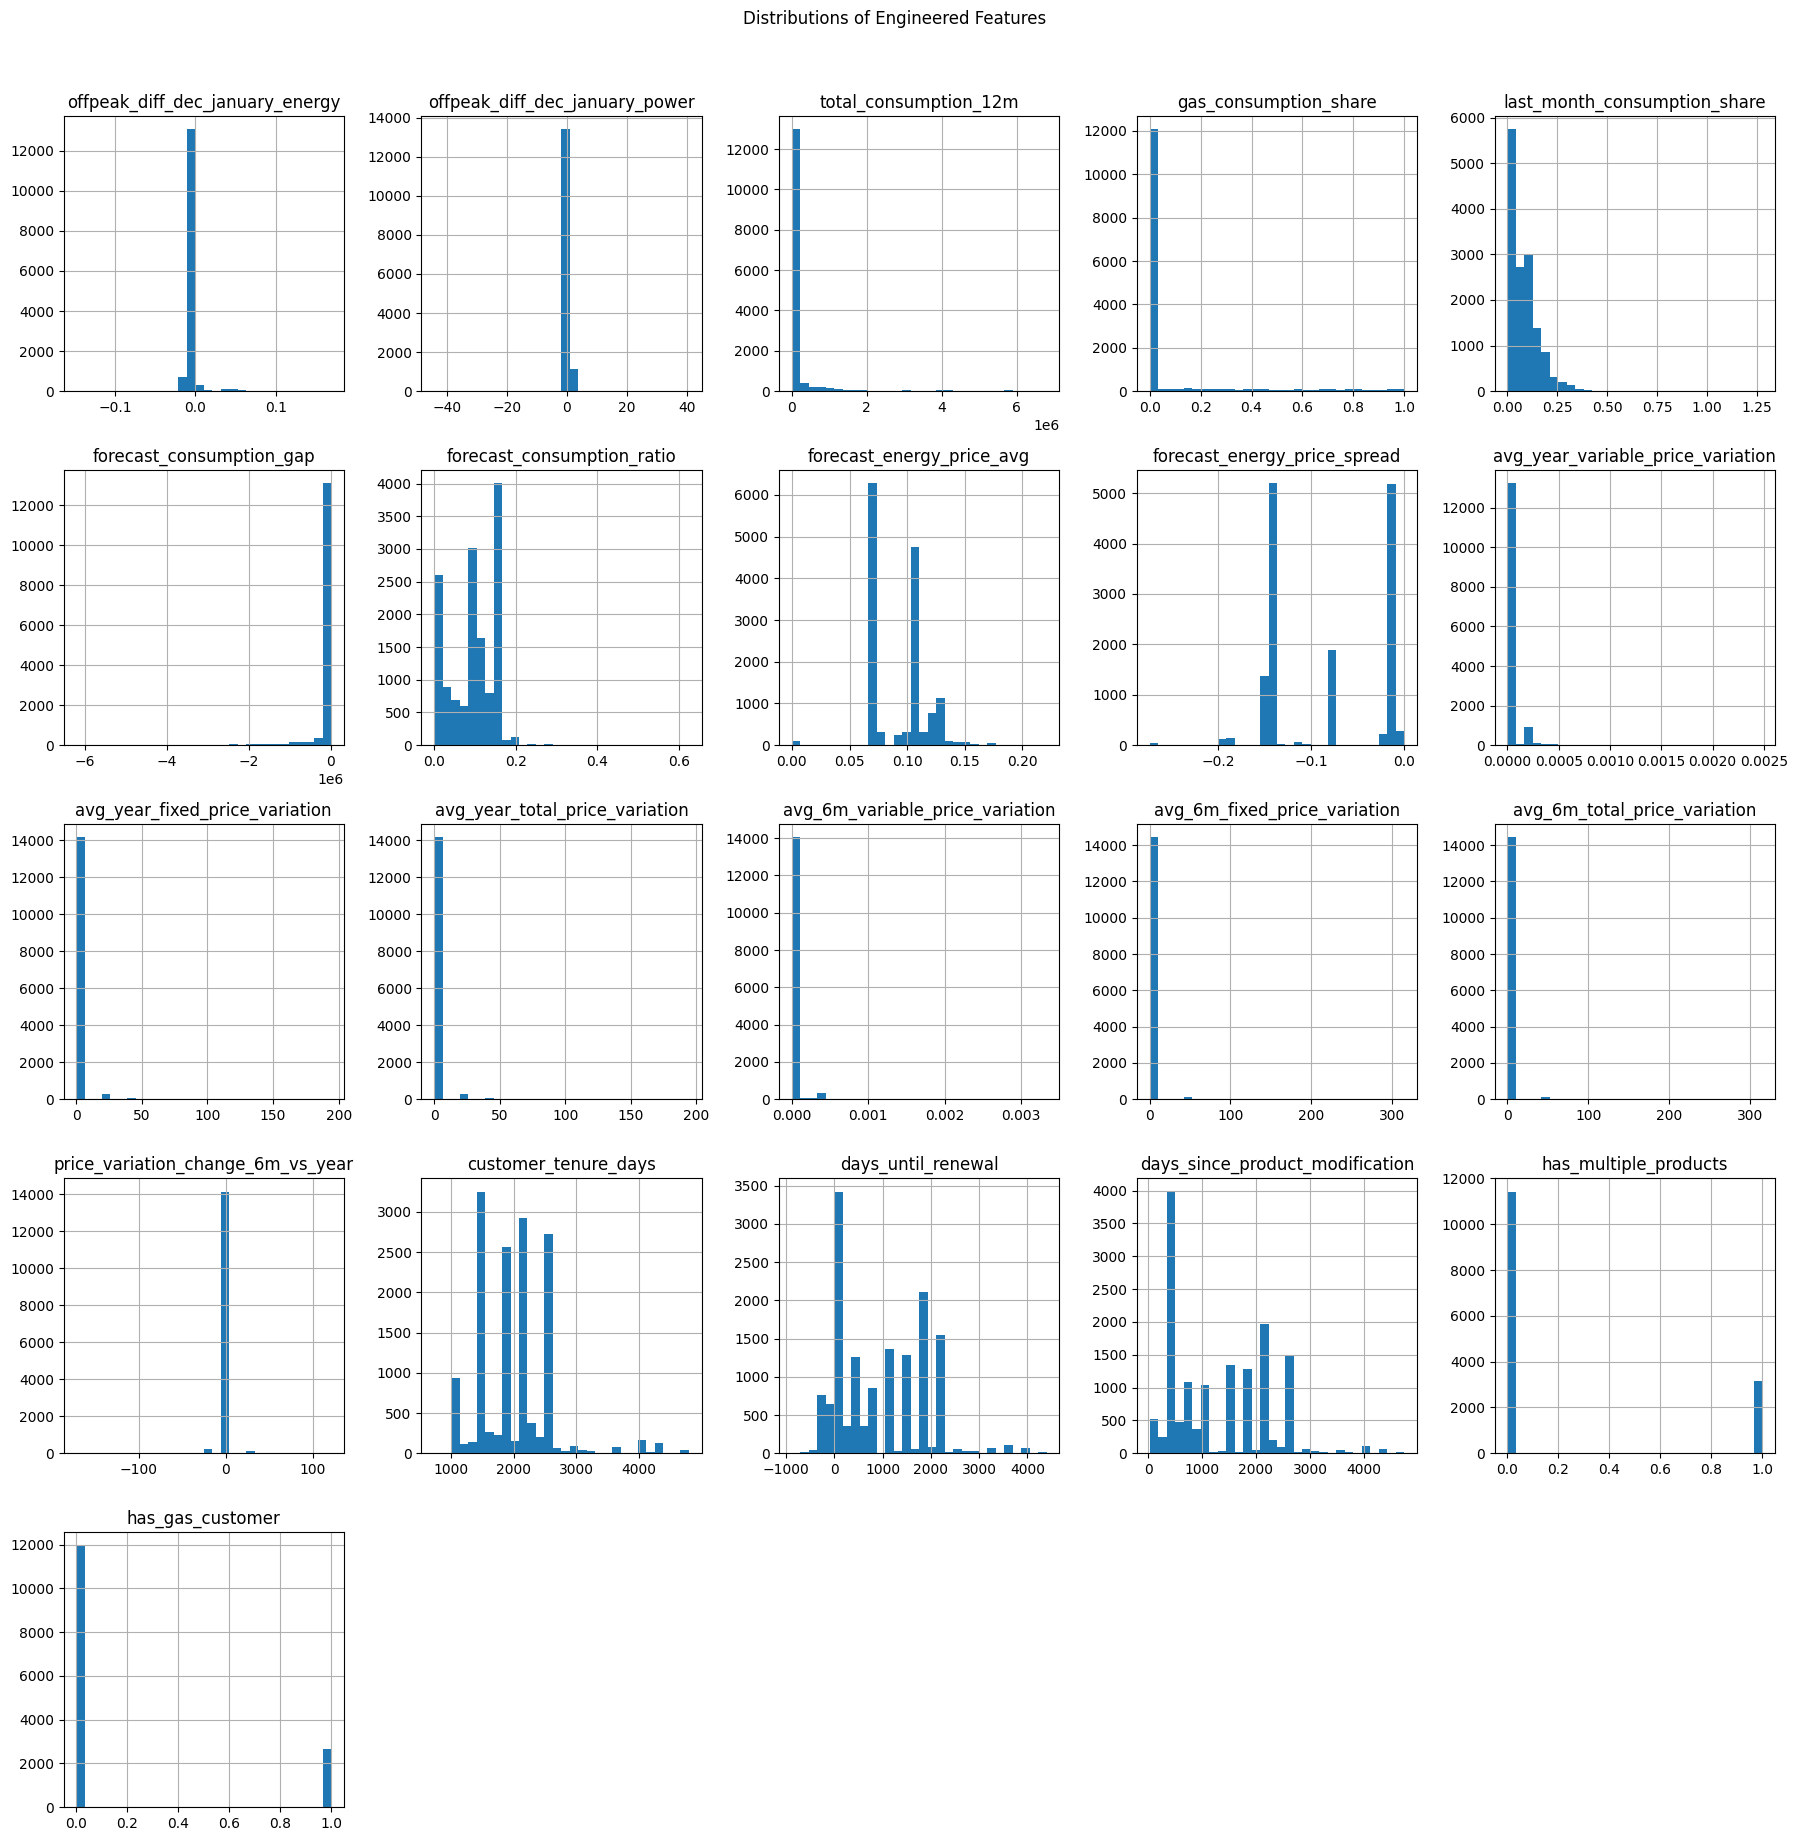

In [10]:
numeric_new_features = [
    col for col in new_features
    if pd.api.types.is_numeric_dtype(df[col])
]

df[numeric_new_features].hist(
    figsize=(18, 18),
    bins=30
)

plt.suptitle("Distributions of Engineered Features", y=1.02)
plt.tight_layout()
plt.show()

## 8. Check engineered-feature summary statistics

In [11]:
feature_summary = df[numeric_new_features].describe().T
feature_summary["missing_values"] = df[numeric_new_features].isna().sum()
feature_summary["unique_values"] = df[numeric_new_features].nunique()

display(feature_summary)

,count,mean,std,min,25%,50%,75%,max,missing_values,unique_values
offpeak_diff_dec_january_energy,"14,606.0000",-0.0046,0.0120,-0.1485,-0.0078,-0.0053,-0.0035,0.1690,0,1971
offpeak_diff_dec_january_power,"14,606.0000",0.2785,1.3492,-44.2669,0.0000,0.1629,0.1778,40.7289,0,114
total_consumption_12m,"14,606.0000","187,312.6616","668,376.8899",0.0000,"6,222.2500","16,339.5000","50,821.7500","6,799,539.0000",0,11325
gas_consumption_share,"14,504.0000",0.0801,0.2131,0.0000,0.0000,0.0000,0.0000,1.0000,102,2172
last_month_consumption_share,"14,489.0000",0.0772,0.0856,0.0000,0.0000,0.0728,0.1127,1.2763,117,8212
forecast_consumption_gap,"14,606.0000","-157,351.6714","573,006.9890","-6,207,018.9900","-37,462.0375","-12,605.7650","-4,961.9275","3,534.2400",0,14469
forecast_consumption_ratio,"14,489.0000",0.0939,0.0548,0.0000,0.0449,0.1024,0.1475,0.6246,117,14260
forecast_energy_price_avg,"14,606.0000",0.0939,0.0235,0.0000,0.0725,0.1036,0.1085,0.2210,0,554
forecast_energy_price_spread,"14,606.0000",-0.0868,0.0617,-0.2740,-0.1449,-0.0786,-0.0163,0.0000,0,415
avg_year_variable_price_variation,"14,606.0000",0.0000,0.0001,0.0000,0.0000,0.0000,0.0000,0.0025,0,4675


## 9. Check the relationship of engineered numerical features with churn

This is an exploratory check only. It does not establish causation.

In [12]:
churn_summary = (
    df.groupby("churn")[numeric_new_features]
      .mean()
      .T
      .rename(columns={0: "No churn", 1: "Churn"})
)

display(churn_summary.sort_values("Churn", ascending=False))

churn,No churn,Churn
total_consumption_12m,"197,988.7639","88,097.8901"
customer_tenure_days,"2,022.2041","1,871.2396"
days_since_product_modification,"1,318.3112","1,153.9859"
days_until_renewal,945.7678,781.1071
avg_year_total_price_variation,1.1837,1.6935
avg_year_fixed_price_variation,1.1837,1.6934
avg_6m_total_price_variation,0.9583,1.4477
avg_6m_fixed_price_variation,0.9583,1.4476
offpeak_diff_dec_january_power,0.2773,0.2895
has_multiple_products,0.2197,0.1959


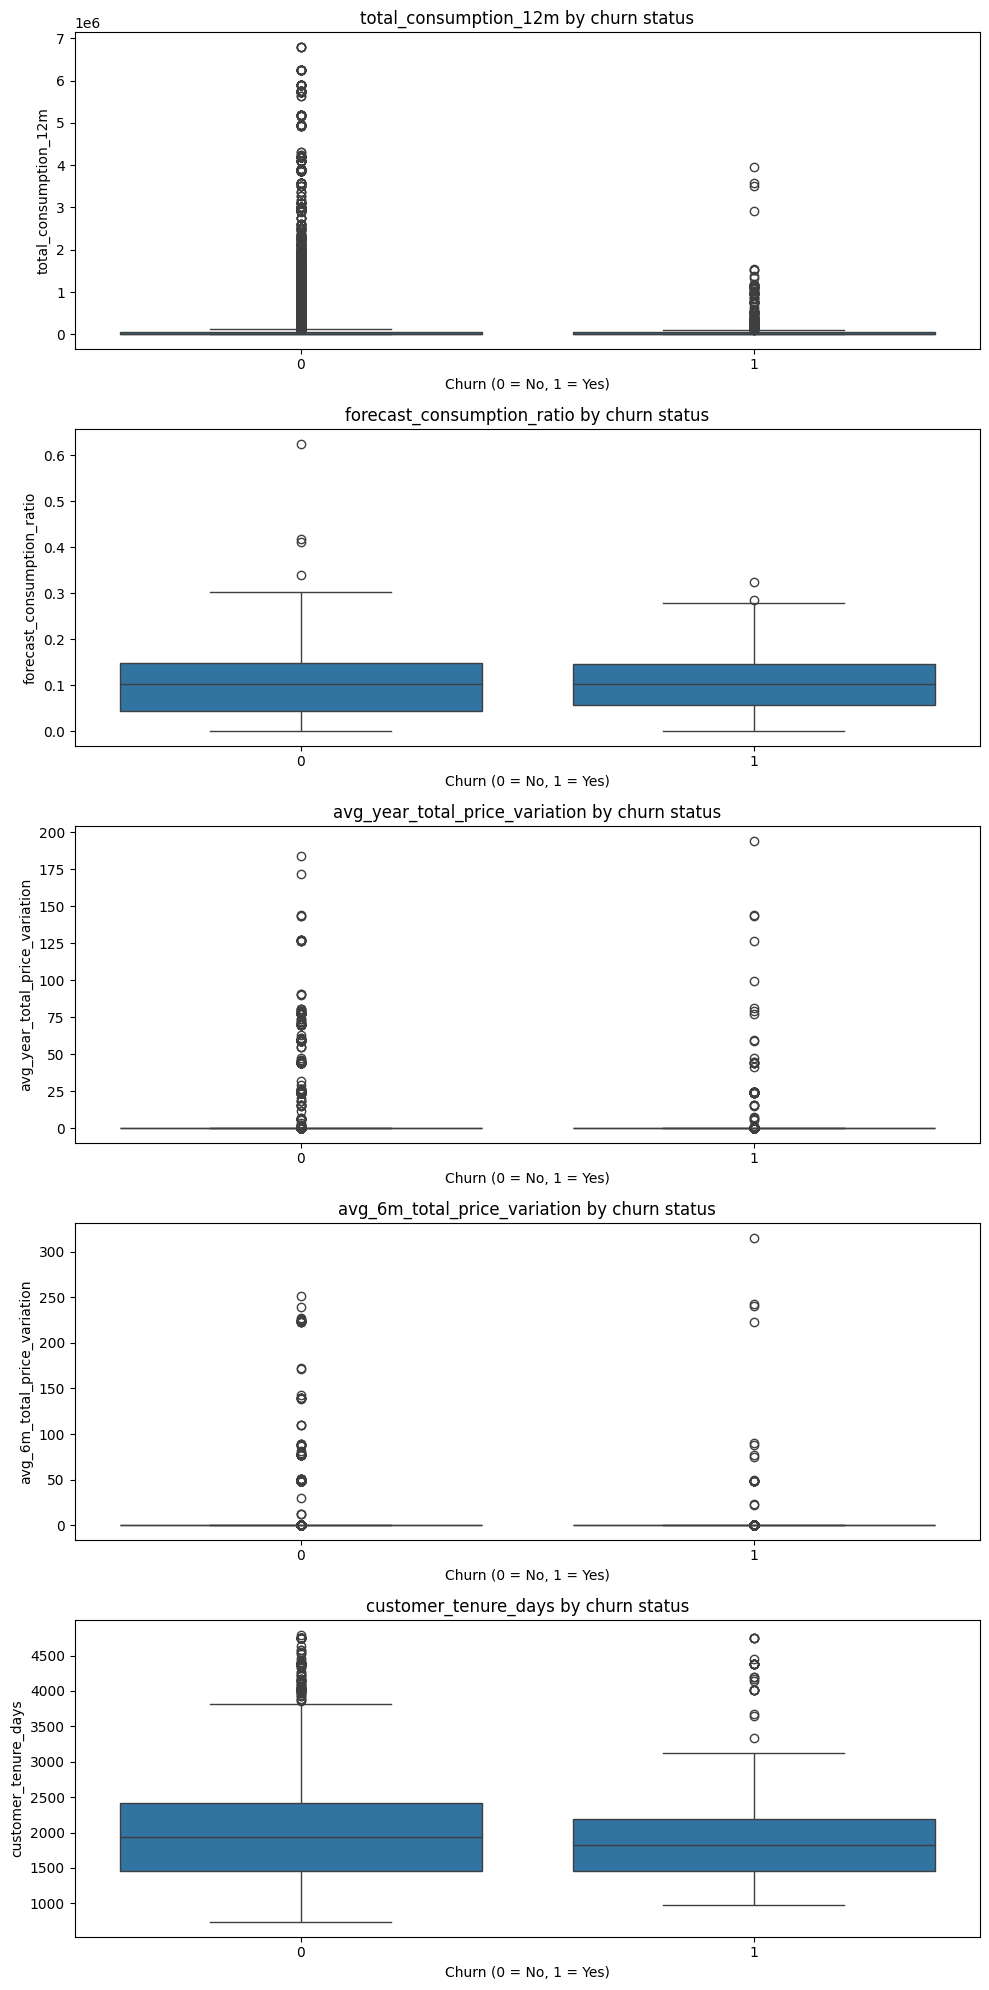

In [13]:
# Visualize selected business-relevant features against churn.
selected_plot_features = [
    "total_consumption_12m",
    "forecast_consumption_ratio",
    "avg_year_total_price_variation",
    "avg_6m_total_price_variation",
    "customer_tenure_days",
]

fig, axes = plt.subplots(
    nrows=len(selected_plot_features),
    ncols=1,
    figsize=(10, 4 * len(selected_plot_features))
)

for ax, feature in zip(axes, selected_plot_features):
    sns.boxplot(data=df, x="churn", y=feature, ax=ax)
    ax.set_title(f"{feature} by churn status")
    ax.set_xlabel("Churn (0 = No, 1 = Yes)")

plt.tight_layout()
plt.show()

## 10. Correlation check

A correlation matrix can help identify strongly related engineered numerical variables. High correlation does not imply causation.

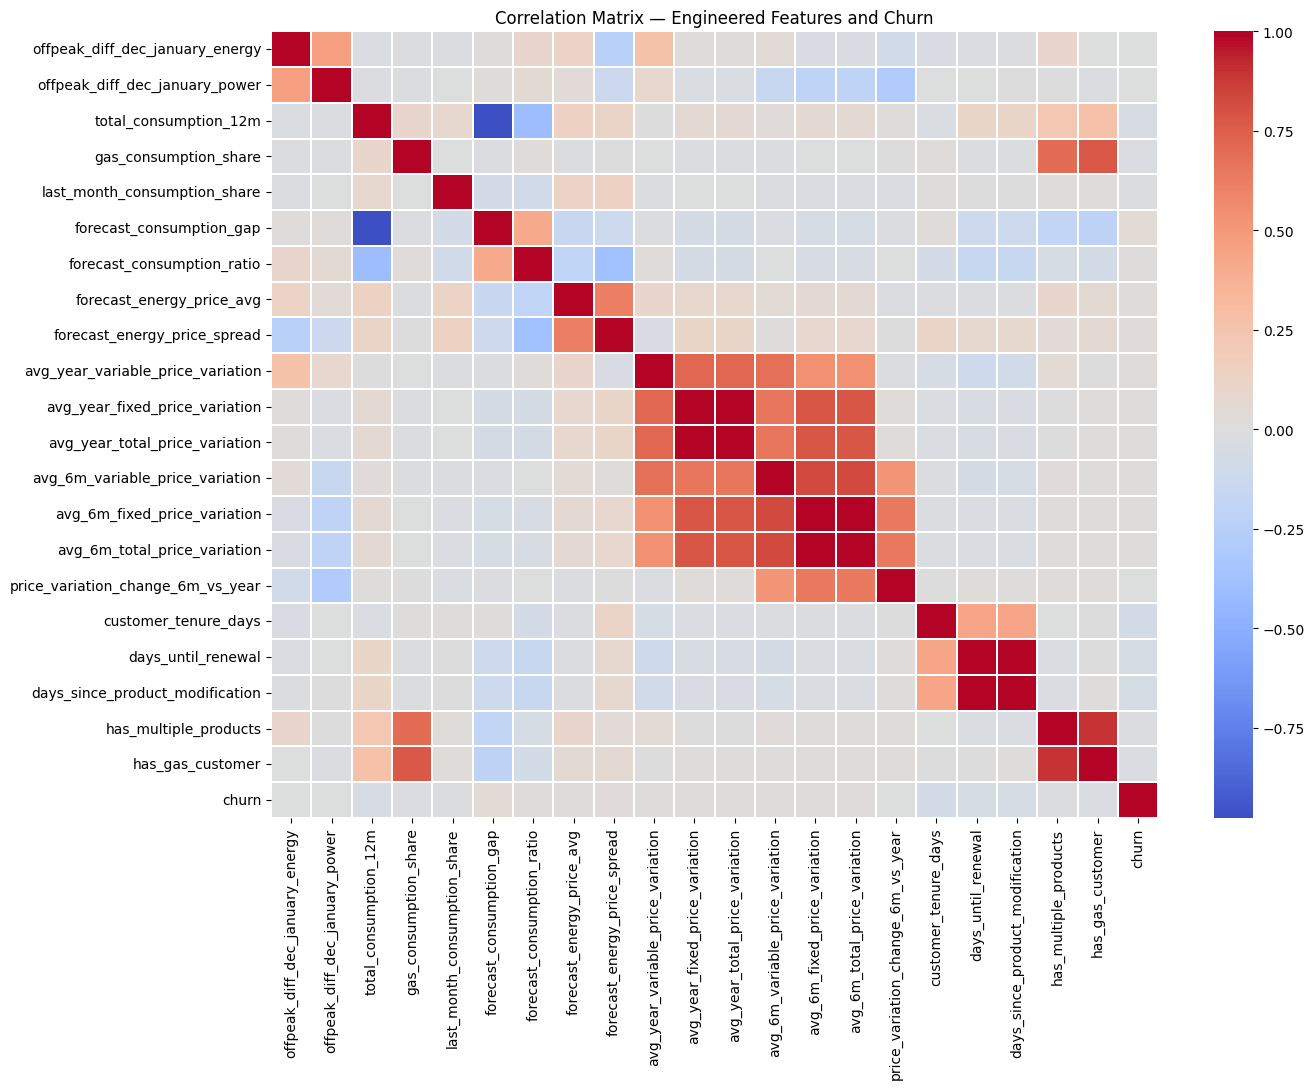

In [14]:
corr = df[numeric_new_features + ["churn"]].corr(numeric_only=True)

plt.figure(figsize=(14, 11))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)
plt.title("Correlation Matrix — Engineered Features and Churn")
plt.tight_layout()
plt.show()

## 11. Final feature-quality checks

In [15]:
# Check for infinite values.
infinite_counts = pd.Series(
    np.isinf(df.select_dtypes(include=np.number)).sum(),
    name="infinite_values"
)

# Check missing values in engineered features.
engineered_quality = pd.DataFrame({
    "dtype": df[new_features].dtypes.astype(str),
    "missing_values": df[new_features].isna().sum(),
    "unique_values": df[new_features].nunique(),
    "infinite_values": infinite_counts.reindex(new_features).fillna(0).astype(int),
})

display(engineered_quality)

,dtype,missing_values,unique_values,infinite_values
offpeak_diff_dec_january_energy,float64,0,1971,0
offpeak_diff_dec_january_power,float64,0,114,0
total_consumption_12m,int64,0,11325,0
gas_consumption_share,float64,102,2172,0
last_month_consumption_share,float64,117,8212,0
forecast_consumption_gap,float64,0,14469,0
forecast_consumption_ratio,float64,117,14260,0
forecast_energy_price_avg,float64,0,554,0
forecast_energy_price_spread,float64,0,415,0
avg_year_variable_price_variation,float64,0,4675,0


## 12. Export the engineered dataset

The target column `churn` is retained because it is required for the later analysis of churn. For predictive modeling, avoid using the target itself as an input feature.

In [16]:
output_file = "powerco_feature_engineered.csv"
df.to_csv(output_file, index=False)

print(f"Saved engineered dataset to: {output_file}")
print(f"Final shape: {df.shape}")

Saved engineered dataset to: powerco_feature_engineered.csv
Final shape: (14606, 65)
